In [2]:
import numpy as np
from matplotlib import pyplot as plt

def load_session_data(subject, date):
    """Load all data for a given subject and date"""
    import sys
    sys.path.append(r'D:\Neural-Pipeline\source')
    from analysis_utils.NeuralDataLoader import NeuralDataLoader, Dots3DMPConfig
    
    # Load session
    loader = NeuralDataLoader()
    loader.load_session(subject, date)
    config = Dots3DMPConfig(subject)

    # spike data (unit, trial, time)
    stimOn_spikes = loader.get_spike_data(alignment='stimOn', good_units_only=True, good_trials_only=True)
    saccOnset_spikes = loader.get_spike_data(alignment='saccOnset', good_units_only=True, good_trials_only=True)
    postTargHold_spikes = loader.get_spike_data(alignment='postTargHold', good_units_only=True, good_trials_only=True)
    tuning_spikes = loader.get_tuning_data(good_units_only=True, good_trials_only=True)

    # behavioral data
    behavior_dots3DMP = loader.get_behavioral_data(task='dots3DMP', good_trials_only=True)
    behavior_tuning = loader.get_behavioral_data(task='tuning', good_trials_only=True)
    behavior_converted = config.convert_behavioral_data(behavior_dots3DMP, task='dots3DMP')
    behavior_tuning_converted = config.convert_behavioral_data(behavior_tuning, task='tuning')

    # Unit Info
    unit_info = loader.get_unit_info(good_units_only=True)
    MST_units = loader.get_units_by_area(unit_info, area_name='MST')
    VPS_units = loader.get_units_by_area(unit_info, area_name='VPS')
    dual_units = loader.get_units_by_area(unit_info, area_name='dual')

    # Time Info
    time_info = config.get_time_Info('dots3DMP')
    time_info_tuning = config.get_time_Info('tuning')
    time_axes_dots3DMP = config.get_time_axes('dots3DMP')

    # Prepare data
    spikes_data = {
        'stimOn': stimOn_spikes,
        'saccOnset': saccOnset_spikes,
        'postTargHold': postTargHold_spikes
    }
    
    units_data = {
        'MST': MST_units,
        'VPS': VPS_units,
        'dual': dual_units
    }
    
    return {
        'loader': loader,
        'config': config,
        'spikes_data': spikes_data,
        'behavior_converted': behavior_converted,
        'behavior_tuning_converted': behavior_tuning_converted,
        'unit_info': unit_info,
        'units_data': units_data,
        'time_axes_dots3DMP': time_axes_dots3DMP,
        'time_info': time_info,
        'time_info_tuning': time_info_tuning
    }


# Function to create file path based on modality/coherence condition
def get_filepath(date, area, alignment, target, mod, coh, regression='decoders'):
    subject = 'zarya'
    if target == 'stimulus':
        trial_condition = 'correct_non_zero'
    elif target == 'choice':    
        trial_condition = 'non_zero'
    elif target == 'PDW':
        trial_condition = 'small_heading_single_target'

    decoder_folder = f"D:\\Neural-Pipeline\\results\\analysis_population\\{regression}"

    return f"{decoder_folder}\\{subject}_{date}_{area}_{target}_{alignment}_train_mod{mod}_coh{coh}_test_mod{mod}_coh{coh}_{trial_condition}_cv_results.npy"






In [3]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

def classify_unit_comprehensive(row):
    threshold = 0.05
    vis_selective = row['vis_pval'] < threshold and row['ves_pval'] > threshold
    ves_selective = row['ves_pval'] < threshold and row['vis_pval'] > threshold
    comb_selective = (row['vis_pval'] < threshold and row['ves_pval'] < threshold) or row['comb_pval'] < threshold
    
    # If not selective for any modality
    if not (vis_selective or ves_selective or comb_selective):
        return 'Non-responsive'
    
    # If only selective for one modality
    if vis_selective and not ves_selective and not comb_selective:
        return 'Visual only'
    
    if ves_selective and not vis_selective and not comb_selective:
        return 'Vestibular only'
    
    # If selective for multiple modalities (multisensory)
    if vis_selective or ves_selective or comb_selective:
        # Check if correlations exist and use Fisher's method for significance
        vis_p = row.get('vis_corr_p', 1.0)
        ves_p = row.get('ves_corr_p', 1.0)
        
        # Check if both correlations exist and are valid
        if (pd.notna(vis_p) and pd.notna(ves_p) and 
            pd.notna(row.get('vis_corr_r')) and pd.notna(row.get('ves_corr_r')) and
            vis_p > 0 and ves_p > 0):  # Avoid log(0)
            
            # Fisher's method: -2 * ln(p1 * p2) follows chi-square with 4 df
            fisher_stat = -2 * (np.log(vis_p) + np.log(ves_p))
            combined_p = 1 - chi2.cdf(fisher_stat, df=4)
            
            # If combined significance is < 0.05
            if combined_p < 0.05:
                vis_positive = row['vis_corr_r'] > 0
                ves_positive = row['ves_corr_r'] > 0
                
                if vis_positive == ves_positive:
                    return 'Multisensory Congruent'
                else:
                    return 'Multisensory Opposite'
            else:
                return 'Multisensory Intermediate'
        else:
            return 'Multisensory Intermediate'
    
    return 'Other'

def get_feature_data_dict(tuning_file, date, area, valid_units=None):
    """Extract neurometric data and return as dictionary"""
    df = pd.read_csv(tuning_file)
    date_data = df[(df['date'] == int(date)) & (df['area'] == area)]
    print(date_data['date'].shape)
    
    if date_data.empty:
        print(f"No data found for date {date} and area {area}")
        return None
    
    # Apply classification
    date_data = date_data.copy()

    if valid_units is not None:
        date_data = date_data[date_data['unit_idx'].isin(valid_units)]
        
    date_data['classification'] = date_data.apply(classify_unit_comprehensive, axis=1)


    
    # Print summary
    # print(f"\nUnit classifications for {area} on {date}:")
    # print(date_data['classification'].value_counts())
    
    return {
        'unit_idx': date_data.get('unit_idx', pd.Series(dtype=int)).values,
        'absolute_depth': date_data.get('absolute_depth', pd.Series(dtype=float)).values,
        'classification': date_data['classification'].values,
        'ves_neurometric': date_data.get('ves_neurometric_threshold', 
                                       date_data.get('ves_neurometric', pd.Series(dtype=float))).values,
        'vis_neurometric': date_data.get('vis_neurometric_threshold',
                                       date_data.get('vis_neurometric', pd.Series(dtype=float))).values,
        'comb_neurometric': date_data.get('comb_neurometric_threshold',
                                        date_data.get('comb_neurometric', pd.Series(dtype=float))).values,
        'dataframe': date_data  # Include full dataframe for additional analysis
    }




In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, f_oneway
import seaborn as sns
from collections import defaultdict
import pandas as pd

def load_session_data(subject, date):
    """Load all data for a given subject and date"""
    import sys
    sys.path.append(r'D:\Neural-Pipeline\source')
    from analysis_utils.NeuralDataLoader import NeuralDataLoader, Dots3DMPConfig
    
    # Load session
    loader = NeuralDataLoader()
    loader.load_session(subject, date)
    config = Dots3DMPConfig(subject)

    # Time Info
    time_info = config.get_time_Info('dots3DMP')
    time_info_tuning = config.get_time_Info('tuning')
    time_axes_dots3DMP = config.get_time_axes('dots3DMP')
    
    return {
        'loader': loader,
        'config': config,
        'time_axes_dots3DMP': time_axes_dots3DMP,
        'time_info': time_info,
        'time_info_tuning': time_info_tuning
    }

def get_filepath(date, area, alignment, target, mod, coh, regression='decoders'):
    subject = 'zarya'
    if target == 'stimulus':
        trial_condition = 'correct_non_zero'
    elif target == 'choice':    
        trial_condition = 'non_zero'
    elif target == 'PDW':
        trial_condition = 'small_heading_single_target'

    decoder_folder = f"D:\\Neural-Pipeline\\results\\analysis_population\\{regression}"
    return f"{decoder_folder}\\{subject}_{date}_{area}_{target}_{alignment}_train_mod{mod}_coh{coh}_test_mod{mod}_coh{coh}_{trial_condition}_cv_results.npy"

def analyze_neurometric_relationship_time():
    """
    Main function to analyze neurometric relationships with time dimension
    """
    
    # Parameters
    dates = ["20250602", "20250702", "20250710", "20250523", "20250501", "20250417"]
    areas = ['VPS', 'MST']
    alignments = ['stimOn', 'saccOnset']
    targets = ['stimulus']
    regression_methods = ['decoders_partialregress', 'decoders_noregress']
    
    # Selected conditions
    selected_conditions = {
        'Vestibular Only': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    # Storage for results with time dimension
    time_results = {}
    
    print("Starting time-based neurometric relationship analysis...")
    
    for date in dates:
        print(f"Processing date: {date}")
        
        # Load session data to get time axes for this specific date
        try:
            session_data = load_session_data('zarya', date)
            time_axes = session_data['time_axes_dots3DMP']
            
            # Get time axes for different alignments
            time_axes_stimOn = time_axes['stimOn']
            time_axes_saccOnset = time_axes['saccOnset']
            
            print(f"Loaded time axes for {date}:")
            print(f"  stimOn: {len(time_axes_stimOn)} time points ({time_axes_stimOn[0]:.1f} to {time_axes_stimOn[-1]:.1f} ms)")
            print(f"  saccOnset: {len(time_axes_saccOnset)} time points ({time_axes_saccOnset[0]:.1f} to {time_axes_saccOnset[-1]:.1f} ms)")
        except Exception as e:
            print(f"Failed to load session data for {date}: {e}")
            continue
            
        for area in areas:
            print(f"\nProcessing area: {area}, date: {date}")
            
            # Load tuning data for this area and date
            tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
            
            try:
                decoder_file = get_filepath(date, area, 'stimOn', 'stimulus', 1, 1, regression='decoders_partialregress')
                decoder_results = np.load(decoder_file, allow_pickle=True).item()
                trial_results = decoder_results['trial_results']
                valid_units = trial_results[0]['unit_idx']
                feature_results = get_feature_data_dict(tuning_file, date, area, valid_units)
                
                # Create lookup dictionaries for quick access
                classifications = feature_results['classification']
                vis_neurometric = feature_results['vis_neurometric']
                ves_neurometric = feature_results['ves_neurometric']
                comb_neurometric = feature_results['comb_neurometric']
                
            except Exception as e:
                print(f"Could not load tuning data for {area}, {date}: {e}")
                continue
            
            for regression_method in regression_methods:
                print(f"  Processing regression method: {regression_method}")
                
                for target in targets:
                    for condition_name, condition_params in selected_conditions.items():
                        mod = condition_params['mod']
                        coh = condition_params['coh']
                        print(f"    Processing condition: {condition_name} (mod={mod}, coh={coh})")
                        
                        for alignment in alignments:
                            print(f"      Processing alignment: {alignment}")
                            
                            # Create analysis key - include date to avoid conflicts
                            analysis_key = f"{date}_{area}_{regression_method}_{condition_name}_{alignment}"
                            
                            # Get appropriate time bins for this alignment from current date's session data
                            if alignment == 'stimOn':
                                time_bins = time_axes_stimOn
                            elif alignment == 'saccOnset':
                                time_bins = time_axes_saccOnset
                            else:
                                print(f"        Unknown alignment: {alignment}, skipping")
                                continue
                            
                            # Load decoder results
                            try:
                                decoder_file = get_filepath(date, area, alignment, target, mod, coh, regression=regression_method)
                                decoder_results = np.load(decoder_file, allow_pickle=True).item()
                                trial_results = decoder_results['trial_results']
                                print(f"        Loaded {len(trial_results)} trials from decoder results")
                            except Exception as e:
                                print(f"        Could not load decoder file: {e}")
                                continue
                            
                            valid_units = trial_results[0]['unit_idx']
                            n_valid_units = len(valid_units)
                            n_time_bins = len(time_bins)
                            n_cv_folds = 10
                           
                            weights_3d = np.full((n_valid_units, n_time_bins, n_cv_folds), np.nan)

                            # Fill the 3D array directly
                            for trial in trial_results:
                                if 'unit_idx' in trial and 'coefficients' in trial:
                                    time_idx = trial['time']  # Get time point index
                                    cv_fold = trial['cv_fold']  # Get CV fold index
                                    coefficients = trial['coefficients'][valid_units]

                                    for unit_idx in range(n_valid_units):
                                        weight = abs(float(coefficients[unit_idx]))   
                                        weights_3d[unit_idx, time_idx, cv_fold] = weight

                            # Average across CV folds (dimension 2)
                            # weights_array = weights_3d
                            weights_array = np.nanmean(weights_3d, axis=2)  # Shape: (n_valid_units, n_time_bins)
                            # Store results
                            time_results[analysis_key] = {
                                'weights': weights_array,  # Shape: (n_valid_units, n_time_bins)
                                'weights_3d': weights_3d,  # Shape: (n_valid_units, n_time_bins, n_cv_folds) 
                                'unit_indices': valid_units,  # Shape: (n_valid_units,)
                                'classifications': classifications,  # Shape: (n_valid_units,)
                                'vis_neurometric': vis_neurometric,  # Shape: (n_valid_units,)
                                'ves_neurometric': ves_neurometric,  # Shape: (n_valid_units,)
                                'comb_neurometric': comb_neurometric,  # Shape: (n_valid_units,)
                                'time_bins': time_bins,  # Shape: (n_time_bins,)
                                'condition_info': {
                                    'date': date, 
                                    'area': area,
                                    'regression_method': regression_method,
                                    'condition_name': condition_name,
                                    'alignment': alignment,
                                    'mod': mod,
                                    'coh': coh,
                                    'n_cv_folds': n_cv_folds
                                }
                            }

                            print(f"        Stored weights array: {weights_array.shape}")
                            print(f"        3D weights array: {weights_3d.shape}")
                            print(f"        Non-NaN weights: {np.sum(~np.isnan(weights_array))}")
    
    return time_results

# Run the time-based analysis
if __name__ == "__main__":
    print("Starting time-based neurometric relationship analysis...")
    
    # Run the time-based analysis
    time_results = analyze_neurometric_relationship_time()
    
    # Print summary
    if time_results:
        print("\n" + "="*60)
        print("TIME-BASED ANALYSIS SUMMARY")
        print("="*60)
        
        for analysis_key, data in time_results.items():
            condition_info = data['condition_info']
            weights_shape = data['weights'].shape
            n_time_bins = len(data['time_bins'])
            
            print(f"\n{analysis_key}:")
            print(f"  Date: {condition_info['date']}")
            print(f"  Weights array shape: {weights_shape}")
            print(f"  Time bins: {n_time_bins}")
            print(f"  Time range: {data['time_bins'][0]:.1f} to {data['time_bins'][-1]:.1f} ms")
            print(f"  Valid units: {len(data['unit_indices'])}")
            print(f"  Non-NaN weights: {np.sum(~np.isnan(data['weights']))}")
            
            # Classification breakdown
            unique_classes, counts = np.unique(data['classifications'], return_counts=True)
            print(f"  Classification breakdown:")
            for cls, count in zip(unique_classes, counts):
                print(f"    {cls}: {count}")
        
    else:
        print("No time-based data found for analysis. Please check file paths and data availability.")

Starting time-based neurometric relationship analysis...
Starting time-based neurometric relationship analysis...
Processing date: 20250602
Loaded dots3DMP data: zarya20250602dots3DMP_processed.npz
Loaded dots3DMPtuning data: zarya20250602dots3DMPtuning_processed.npz
Loaded dots3DMP configuration for subject: zarya
Loaded time axes for 20250602:
  stimOn: 51 time points (-0.1 to 0.9 ms)
  saccOnset: 51 time points (-0.6 to 0.4 ms)

Processing area: VPS, date: 20250602
(86,)
  Processing regression method: decoders_partialregress
    Processing condition: Vestibular Only (mod=1, coh=1)
      Processing alignment: stimOn
        Loaded 510 trials from decoder results
        Stored weights array: (86, 51)
        3D weights array: (86, 51, 10)
        Non-NaN weights: 4386
      Processing alignment: saccOnset
        Loaded 510 trials from decoder results
        Stored weights array: (86, 51)
        3D weights array: (86, 51, 10)
        Non-NaN weights: 4386
    Processing condition:


Creating pooled figure for VPS


C:\Users\fetschlab\AppData\Local\Temp\ipykernel_6204\4210485823.py:141: RuntimeWarning: Mean of empty slice
  mean_abs_weights = np.nanmean(np.abs(cls_weights), axis=0)
c:\Users\fetschlab\Desktop\spike_interface\.venv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


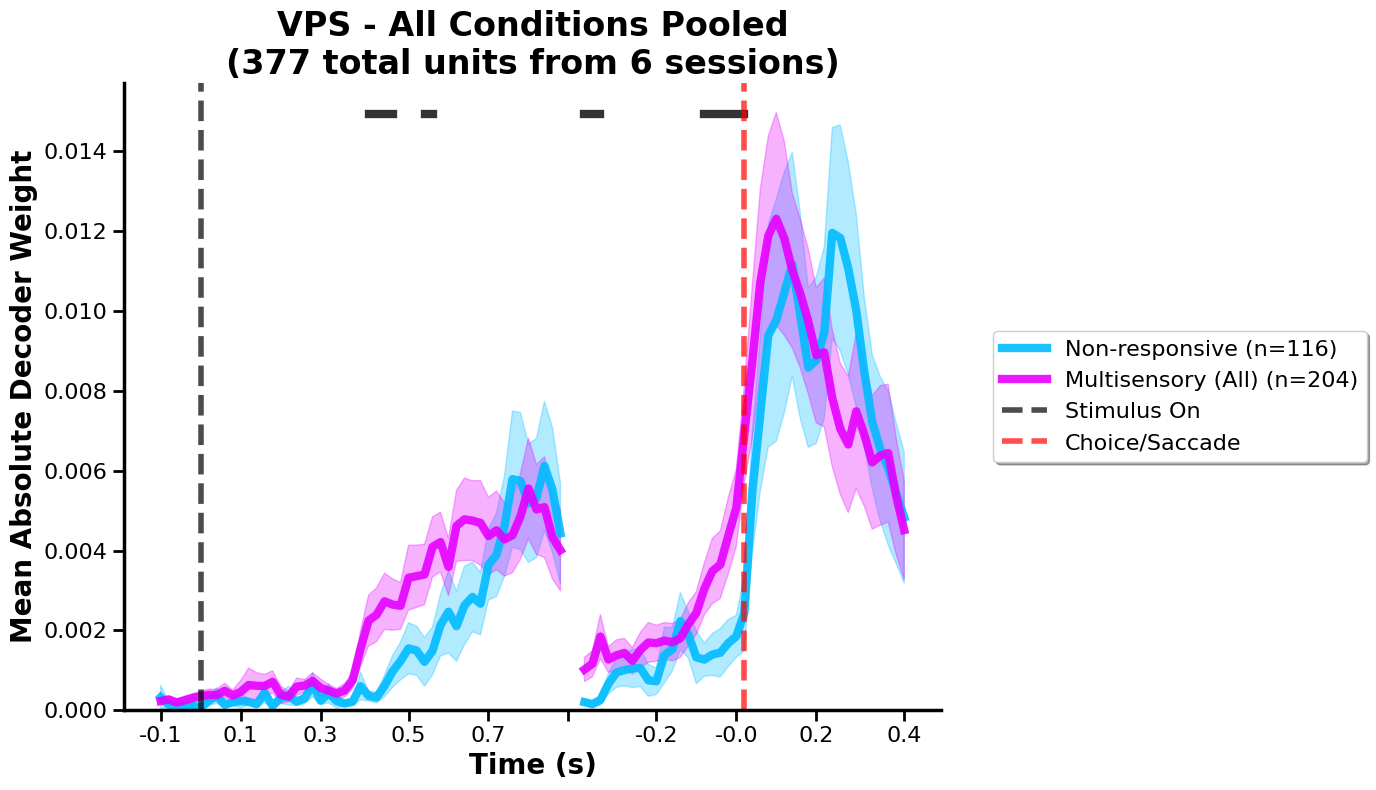


Summary for VPS:
  Total units: 1885
  Sessions: 6
  Non-responsive: n=580
    Peak weight: 0.0119
  Multisensory (All): n=1020
    Peak weight: 0.0123
  Significant time points: 19 / 94

Creating pooled figure for MST


C:\Users\fetschlab\AppData\Local\Temp\ipykernel_6204\4210485823.py:141: RuntimeWarning: Mean of empty slice
  mean_abs_weights = np.nanmean(np.abs(cls_weights), axis=0)
c:\Users\fetschlab\Desktop\spike_interface\.venv\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


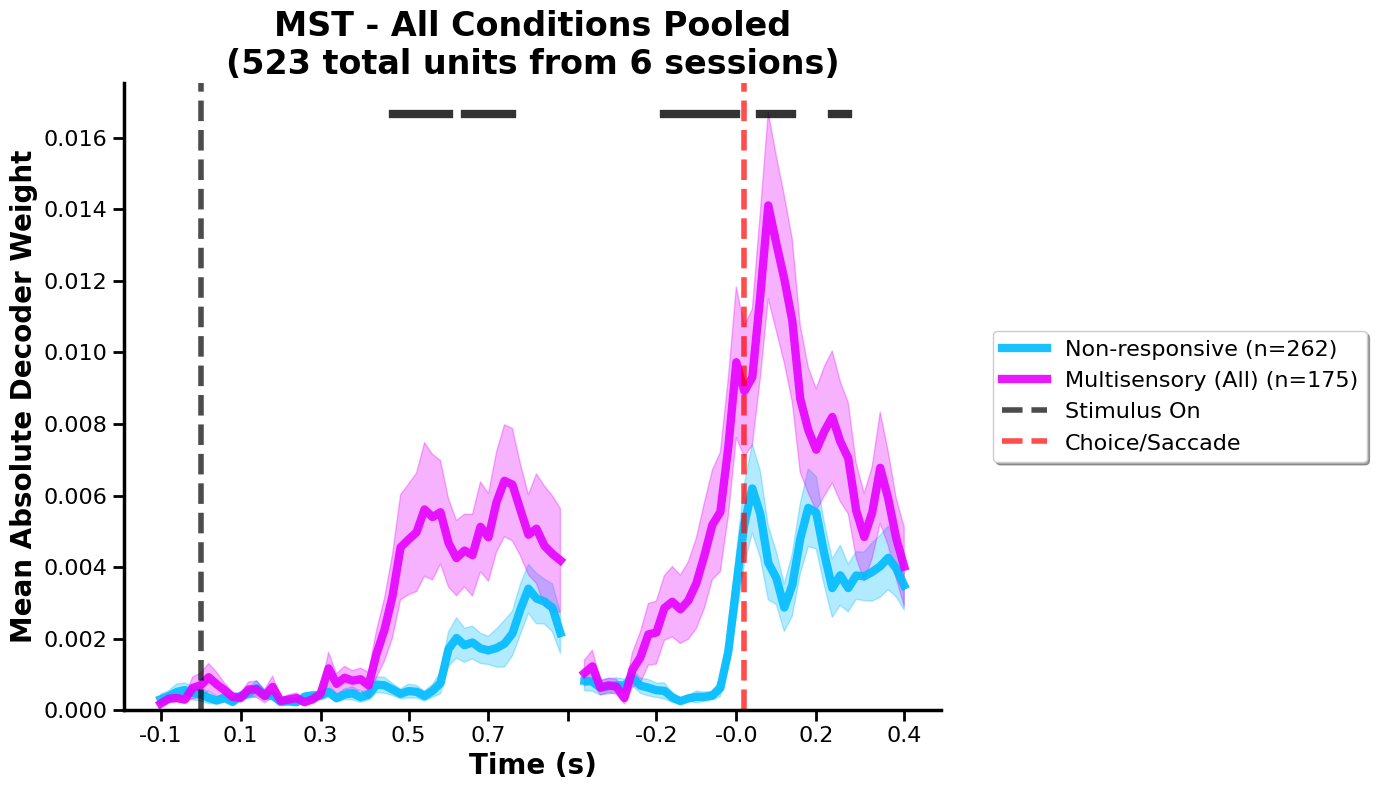


Summary for MST:
  Total units: 2615
  Sessions: 6
  Non-responsive: n=1310
    Peak weight: 0.0062
  Multisensory (All): n=875
    Peak weight: 0.0141
  Significant time points: 33 / 94


In [5]:
def plot_weights_by_classification_pooled_all_conditions(time_results):
    """
    Plot mean weights by neural classification pooled across ALL conditions
    Shows only Non-responsive and Multisensory (combined) classifications
    Shows only no regress results
    """
    
    from scipy import stats as scipy_stats  # Renamed to avoid conflict
    from collections import defaultdict
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Define plot groups and colors
    plot_groups = {
        'Non-responsive': ['Non-responsive'],
        'Multisensory (All)': ['Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']
    }
    
    plot_colors = {
        'Non-responsive': "#00bbff",
        'Multisensory (All)': "#e600ff"
    }
    
    # Group results by area
    area_results = defaultdict(lambda: {
        'stim_weights': [],
        'stim_classifications': [],
        'sacc_weights': [],
        'sacc_classifications': [],
        'stim_time_bins': None,
        'sacc_time_bins': None,
        'dates': set()
    })
    
    # Collect all data
    for analysis_key, data in time_results.items():
        condition_info = data['condition_info']
        area = condition_info['area']
        regression_method = condition_info['regression_method']
        alignment = condition_info['alignment']
        date = condition_info['date']
        
        # Only include no regress results
        if 'noregress' not in regression_method.lower():
            continue
        
        weights = data['weights']
        classifications = data['classifications']
        time_bins = data['time_bins']
        
        # Reshape weights if needed
        if len(weights.shape) == 3:
            n_units, n_time, n_cv = weights.shape
            weights_reshaped = weights.transpose(0, 2, 1).reshape(n_units * n_cv, n_time)
            classifications_expanded = np.repeat(classifications, n_cv)
        else:
            weights_reshaped = weights
            classifications_expanded = classifications
        
        # Store by alignment
        if alignment == 'stimOn':
            area_results[area]['stim_weights'].append(weights_reshaped)
            area_results[area]['stim_classifications'].extend(classifications_expanded)
            area_results[area]['stim_time_bins'] = time_bins
        elif alignment == 'saccOnset':
            # Keep only -400ms to end for saccade
            sacc_mask = time_bins >= -0.4
            sacc_weights = weights_reshaped[:, sacc_mask]
            area_results[area]['sacc_weights'].append(sacc_weights)
            area_results[area]['sacc_classifications'].extend(classifications_expanded)
            area_results[area]['sacc_time_bins'] = time_bins[sacc_mask]
        
        area_results[area]['dates'].add(date)
    
    # Create figure for each area
    figures = {}
    
    for area, area_data in area_results.items():
        if not area_data['stim_weights'] or not area_data['sacc_weights']:
            print(f"Skipping {area} - missing alignment data")
            continue
        
        print(f"\nCreating pooled figure for {area}")
        
        # Combine stimulus and saccade aligned data
        stim_weights_combined = np.vstack(area_data['stim_weights'])
        sacc_weights_combined = np.vstack(area_data['sacc_weights'])
        stim_classifications = np.array(area_data['stim_classifications'])
        stim_time_bins = area_data['stim_time_bins']
        sacc_time_bins = area_data['sacc_time_bins']
        
        # Create combined weights matrix with gap
        n_gap_bins = 2
        n_stim_bins = len(stim_time_bins)
        n_sacc_bins = len(sacc_time_bins)
        n_total_bins = n_stim_bins + n_gap_bins + n_sacc_bins
        
        n_units = stim_weights_combined.shape[0]
        combined_weights = np.full((n_units, n_total_bins), np.nan)
        
        # Fill data
        combined_weights[:, :n_stim_bins] = stim_weights_combined
        sacc_start_idx = n_stim_bins + n_gap_bins
        combined_weights[:, sacc_start_idx:] = sacc_weights_combined
        
        # Create x-axis positions
        x_positions = np.arange(n_total_bins)
        
        # Find reference line positions
        stim_zero_idx = np.argmin(np.abs(stim_time_bins))
        stim_zero_position = stim_zero_idx
        sacc_zero_idx = np.argmin(np.abs(sacc_time_bins))
        sacc_zero_position = sacc_start_idx + sacc_zero_idx
        
        # Create time labels
        time_labels = np.concatenate([
            stim_time_bins,
            [np.nan, np.nan],
            sacc_time_bins
        ])
        
        # Create figure - LARGER for poster
        fig, ax = plt.subplots(1, 1, figsize=(14, 8))
        
        # Store data for statistical comparison
        group_data_for_stats = {}
        
        # Plot each group
        for group_name, classifications_in_group in plot_groups.items():
            # Create group mask
            group_mask = np.zeros(len(stim_classifications), dtype=bool)
            for classification in classifications_in_group:
                group_mask |= (stim_classifications == classification)
            
            n_units_in_group = np.sum(group_mask)
            
            if n_units_in_group > 0:
                cls_weights = combined_weights[group_mask, :]
                
                # Calculate statistics
                mean_abs_weights = np.nanmean(np.abs(cls_weights), axis=0)
                std_abs_weights = np.nanstd(np.abs(cls_weights), axis=0, ddof=1)
                sem_weights = std_abs_weights / np.sqrt(n_units_in_group)
                
                # Store for statistical testing
                group_data_for_stats[group_name] = {
                    'mean': mean_abs_weights,
                    'std': std_abs_weights,
                    'n': n_units_in_group,
                    'raw_data': cls_weights  # Keep raw data for verification
                }
                
                # Plot with THICKER lines for poster
                color = plot_colors[group_name]
                label = f'{group_name} (n={n_units_in_group // 5})'  # Integer division for cleaner display
                
                ax.plot(x_positions, mean_abs_weights, '-', color=color,
                       linewidth=6, label=label, alpha=0.9)  # Increased from 2.5 to 4
                ax.fill_between(x_positions,
                               mean_abs_weights - sem_weights,
                               mean_abs_weights + sem_weights,
                               alpha=0.3, color=color)
        
        # Statistical comparison
        if len(group_data_for_stats) == 2:
            group_names = list(group_data_for_stats.keys())
            group1_stats = group_data_for_stats[group_names[0]]  # Renamed variable
            group2_stats = group_data_for_stats[group_names[1]]  # Renamed variable
            
            p_values = []
            
            for t_idx in range(n_total_bins):
                if np.isnan(group1_stats['mean'][t_idx]) or np.isnan(group2_stats['mean'][t_idx]):
                    p_values.append(1.0)
                    continue
                
                # Use stored statistics
                mean1 = group1_stats['mean'][t_idx]
                mean2 = group2_stats['mean'][t_idx]
                std1 = group1_stats['std'][t_idx]
                std2 = group2_stats['std'][t_idx]
                n1 = group1_stats['n']
                n2 = group2_stats['n']
                
                # Welch's t-test
                se = np.sqrt((std1**2/n1) + (std2**2/n2))
                
                if se > 0:
                    t_stat = (mean1 - mean2) / se
                    df = (std1**2/n1 + std2**2/n2)**2 / ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))
                    p_val = 2 * (1 - scipy_stats.t.cdf(abs(t_stat), df))  # Use scipy_stats here
                    p_values.append(p_val)
                else:
                    p_values.append(1.0)
            
            # Plot significance
            p_values = np.array(p_values)
            alpha = 0.05
            significant_mask = p_values < alpha
            
            if np.any(significant_mask):
                y_max = ax.get_ylim()[1]
                sig_y = y_max * 0.95
                
                # Find continuous segments
                sig_indices = np.where(significant_mask)[0]
                segments = []
                current_segment = [sig_indices[0]]
                
                for i in range(1, len(sig_indices)):
                    if sig_indices[i] == sig_indices[i-1] + 1:
                        current_segment.append(sig_indices[i])
                    else:
                        segments.append(current_segment)
                        current_segment = [sig_indices[i]]
                segments.append(current_segment)
                
                # Draw significance bars - THICKER for poster
                for segment in segments:
                    start_x = x_positions[segment[0]]
                    end_x = x_positions[segment[-1]]
                    ax.plot([start_x, end_x], [sig_y, sig_y], 
                           color='black', linewidth=6, alpha=0.8)  # Increased from 3 to 5
                

        
        # Add reference lines - THICKER for poster
        ax.axvline(x=stim_zero_position, color='black', linestyle='--',
                  alpha=0.7, linewidth=4, label='Stimulus On')  # Increased from 1.5 to 3
        ax.axvline(x=sacc_zero_position, color='red', linestyle='--',
                  alpha=0.7, linewidth=4, label='Choice/Saccade')  # Increased from 1.5 to 3
        
        # Customize x-axis
        n_ticks = 10
        tick_indices = np.linspace(0, n_total_bins-1, n_ticks, dtype=int)
        tick_positions = x_positions[tick_indices]
        tick_labels = []
        
        for idx in tick_indices:
            if idx < n_stim_bins:
                tick_labels.append(f'{time_labels[idx]:.1f}')
            elif idx < n_stim_bins + n_gap_bins:
                tick_labels.append('')
            else:
                tick_labels.append(f'{time_labels[idx]:.1f}')
        
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=16)  # Larger tick labels
        ax.tick_params(axis='y', labelsize=16)  # Larger y-axis tick labels
        
        # Formatting - LARGER fonts for poster
        ax.set_xlabel('Time (s)', fontsize=20, fontweight='bold')  # Increased from 14
        ax.set_ylabel('Mean Absolute Decoder Weight', fontsize=20, fontweight='bold')  # Increased from 14
        ax.set_title(f'{area} - All Conditions Pooled\n({n_units // 5} total units from {len(area_data["dates"])} sessions)',
                    fontsize=24, fontweight='bold')  # Increased from 16
        ax.legend(fontsize=16, loc='center left', bbox_to_anchor=(1.05, 0.5),  # Increased from 12
          frameon=True, fancybox=True, shadow=True)
        ax.set_ylim(bottom=0)
        # ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)  # Slightly thicker grid
        
        # Clean up spines - THICKER for poster
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(2.5)  # Increased from 1.5
        ax.spines['bottom'].set_linewidth(2.5)  # Increased from 1.5
        
        # Thicker tick marks
        ax.tick_params(width=2, length=8)  # Thicker and longer ticks
        
        plt.tight_layout()
        
        # Save figure with higher DPI for poster
        save_path = f"D:\\Neural-Pipeline\\results\\analysis_population\\weights_by_classification_{area}_ALL_CONDITIONS_POOLED_POSTER.png"
        plt.savefig(save_path, dpi=600, bbox_inches='tight')  # Increased DPI from 300 to 600
        plt.show()
        
        figures[area] = fig
        
        # Print summary statistics
        print(f"\nSummary for {area}:")
        print(f"  Total units: {n_units}")
        print(f"  Sessions: {len(area_data['dates'])}")
        for group_name, stats_data in group_data_for_stats.items():
            print(f"  {group_name}: n={stats_data['n']}")
            print(f"    Peak weight: {np.nanmax(stats_data['mean']):.4f}")
        print(f"  Significant time points: {np.sum(significant_mask)} / {len(p_values)}")
    
    return figures

# Call the function
figures = plot_weights_by_classification_pooled_all_conditions(time_results)